In [3]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

# src 경로 등록 + config 로드
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from bootstrap import setup_notebook
ROOT, cfg, _vars = setup_notebook("apple.yaml") # target concept
globals().update(_vars)

import os
import json
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import StableDiffusionPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
if "pipe" not in globals():
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    pipe = pipe.to(DEVICE)
    pipe.safety_checker = None
    pipe.set_progress_bar_config(disable=True)

In [5]:
# 02_load_and_analyze 캐시 (선행 노트북 실행 후 사용)
from load import load_cache
_cache = load_cache(cfg, "load_and_analyze")
ff_in = _cache["ff_in"]
W2 = _cache["W2"]
b2 = _cache["b2"]
top_k_idx = _cache["top_k_idx"]
signed_dist = _cache["signed_dist"]
W2_topk = _cache["W2_topk"]
b2_topk = _cache["b2_topk"]
N = int(_cache["N"])
images = _cache.get("images")
if images is None:
    from load import load_images_and_ff_in
    images, _, _ = load_images_and_ff_in(cfg)


cache loaded ← /project/dam/data/apple/up_blocks_1/_cache/load_and_analyze.pt  keys=['ff_in', 'W2', 'b2', 'top_k_idx', 'signed_dist', 'W2_topk', 'b2_topk', 'N']


# Gate hyperplane 부호(binary) 계산 & 후보 뉴런

In [6]:
import torch.nn.functional as F

# 각 이미지의 hyperplane 부호: spatial mean → pre-GELU sign
h_mean   = ff_in.mean(dim=1)                   # (N, 1280)
pre_acts = h_mean @ W2.T + b2                  # (N, 5120)  pre-GELU
binary   = (pre_acts > 0).int()                # (N, 5120)  hyperplane 부호

# 평면 선택 후보: 이진 분산이 높은(50:50 split에 가까운) 상위 K_CAND개 뉴런
# (실제 평면 선택은 아래 'gate-space coherence 최대화' 셀에서 수행)
K_CAND   = 500
bin_var  = binary.float().var(dim=0)           # (5120,)
cand_idx = bin_var.topk(K_CAND).indices.tolist()
print(f"binary shape = {tuple(binary.shape)}  |  후보 뉴런 {len(cand_idx)}개 (top binary-variance)")

binary shape = (100, 5120)  |  후보 뉴런 500개 (top binary-variance)


# 정량 실험

In [7]:
import torchvision.transforms as T

# DINOv2 via torch.hub (transformers 4.25는 dinov2 미지원)
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', pretrained=True)
dino.eval()

tfm = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dino_embeds = []
BS = 16
for i in range(0, N, BS):
    batch = torch.stack([tfm(img) for img in images[i:i+BS]])
    with torch.no_grad():
        feats = dino(batch)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    dino_embeds.append(feats.cpu())

dino_embeds = torch.cat(dino_embeds).numpy()   # (N, 768)
print(f"DINOv2 embeds: {dino_embeds.shape}")


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 embeds: (100, 768)


## Multi-resolution 비교: plane 수(=region 수)에 따른 coherence

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Multi-resolution 비교 (공정비교 버전): plane 1~4개 (= region 2/4/8/16개)
#   Hyperplane(ours) vs K-means(gate, 동일 P-뉴런 예산) vs K-means(DINOv2, oracle) vs Random
#   · 평면 선택 = gate-space coherence 최대화 (균형 제약, DINOv2 미사용 → leakage X)
#   · 이미지 5장 이하(<=5)인 region/cluster 는 무시 (해당 이미지 제외)
# ════════════════════════════════════════════════════════════════════════════
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

N_SELECT_PLANES = 200   # greedy 평면 선택 개수
# KMeans 제약: K=2^P <= N_img. 논문 비교는 plane 1~4 (region 2/4/8/16)
MAX_COMPARE_PLANES = None  # 아래에서 N_img 기준으로 설정
MIN_REGION  = 5     # 이 값 '이하'인 group 무시
BALANCE_MIN = 12    # 평면 단독 split에서 min(n+, n-) 하한 (degenerate 분할 방지)

binary_np = binary.cpu().numpy()
N_img     = len(dino_embeds)
MAX_COMPARE_PLANES = min(4, int(np.floor(np.log2(max(N_img, 2)))))
print(f'N_img={N_img}  compare planes P=1..{MAX_COMPARE_PLANES}  (K up to {2**MAX_COMPARE_PLANES})')

def hyperplane_code(planes):
    cols = binary_np[:, planes]                                 # (N, P) in {0,1}
    return (cols * (1 << np.arange(cols.shape[1]))).sum(axis=1).astype(int)

# ── gate-space 정규화 임베딩 (① 평면선택 / ② kmeans-gate 입력에 사용) ─────────
gate_img   = F.gelu(ff_in @ W2.T + b2).mean(dim=1).cpu().numpy()   # (N, 5120)
pca_gate10 = PCA(n_components=10, random_state=42).fit_transform(gate_img)
gate_feat  = pca_gate10 / (np.linalg.norm(pca_gate10, axis=1, keepdims=True) + 1e-8)

def _gap_in_space(embeds, labels, min_size):
    """주어진 공간에서 작은 group 제외 후 intra-inter gap (선택 기준용, 빠른 버전)."""
    labels = np.asarray(labels)
    keep   = [l for l in np.unique(labels) if (labels == l).sum() > min_size]
    mask   = np.isin(labels, keep)
    e, lab = embeds[mask], labels[mask]
    if len(np.unique(lab)) < 2 or len(lab) < 4:
        return -np.inf
    sim  = e @ e.T
    iu   = np.triu_indices(len(lab), k=1)
    same = lab[iu[0]] == lab[iu[1]]
    pair = sim[iu]
    return float(pair[same].mean() - pair[~same].mean())

# ── ① 평면 선택: gate-space partition coherence 최대화 (균형 제약) ─────────────
col_pos  = binary_np.sum(axis=0)
balanced = [j for j in cand_idx
            if min(int(col_pos[j]), N_img - int(col_pos[j])) >= BALANCE_MIN]
sel = []
for _step in range(N_SELECT_PLANES):
    best_j, best_g = None, -np.inf
    for j in balanced:
        if j in sel:
            continue
        g = _gap_in_space(gate_feat, hyperplane_code(sel + [j]), MIN_REGION)
        if g > best_g:
            best_g, best_j = g, j
    sel.append(best_j)
    # print(f"plane {_step+1}: neuron #{best_j}  gate-gap={best_g:+.4f}")
print("선택된 평면(순서대로):", sel)

# ── 최종 평가용: DINOv2 공간 gap / silhouette (작은 group 무시) ────────────────
def gap_filtered(embeds, labels, min_size=MIN_REGION):
    labels = np.asarray(labels)
    keep   = [l for l in np.unique(labels) if (labels == l).sum() > min_size]
    mask   = np.isin(labels, keep)
    e, lab = embeds[mask], labels[mask]
    if len(np.unique(lab)) < 2 or len(lab) < 4:
        return dict(intra=np.nan, inter=np.nan, gap=np.nan, sil=np.nan,
                    n_used=int(mask.sum()), n_groups=len(keep))
    sim  = e @ e.T
    iu   = np.triu_indices(len(lab), k=1)
    same = lab[iu[0]] == lab[iu[1]]
    pair = sim[iu]
    intra, inter = float(pair[same].mean()), float(pair[~same].mean())
    try:
        sil = float(silhouette_score(e, lab))
    except Exception:
        sil = np.nan
    return dict(intra=intra, inter=inter, gap=intra - inter, sil=sil,
                n_used=int(mask.sum()), n_groups=len(keep))

# ── plane 수(=region 수)별 비교 ───────────────────────────────────────────────
rng_mr  = np.random.default_rng(42)
records = []
print(f"\n{'P':>2} {'K':>3}  {'method':18s}  {'gap':>8}  {'sil':>7}  groups   imgs")
for P in range(1, MAX_COMPARE_PLANES + 1):
    K = 2 ** P
    # ② K-means(gate): ours와 동일하게 '선택된 P개 뉴런'의 연속 활성만 입력
    feat_P = StandardScaler().fit_transform(gate_img[:, sel[:P]])      # (N, P)
    labelings = {
        'Hyperplane (ours)': hyperplane_code(sel[:P]),
        'K-means (gate)':    KMeans(K, random_state=42, n_init=10).fit_predict(feat_P),
        'K-means (DINOv2)':  KMeans(K, random_state=42, n_init=10).fit_predict(dino_embeds),
        'Random':            rng_mr.integers(0, K, size=N_img),
    }
    for name, lab in labelings.items():
        r = gap_filtered(dino_embeds, lab)
        r.update(P=P, K=K, method=name, gap_per_bit=r['gap'] / P)
        records.append(r)
        print(f"{P:>2} {K:>3}  {name:18s}  {r['gap']:+.4f}  {r['sil']:+.4f}  "
              f"{r['n_groups']:>2}/{K:<2}   {r['n_used']:>3}/{N_img}")

# ── ③ oracle 대비 달성률(%) 계산 ──────────────────────────────────────────────
for P in range(1, MAX_COMPARE_PLANES + 1):
    K = 2 ** P
    g_oracle = next(r['gap'] for r in records if r['method'] == 'K-means (DINOv2)' and r['K'] == K)
    for r in records:
        if r['K'] == K:
            r['oracle_frac'] = 100.0 * r['gap'] / g_oracle if g_oracle and g_oracle > 0 else np.nan

# ── 시각화: 3패널 (gap / oracle 달성률 / plane당 효율) ─────────────────────────
order   = ['K-means (DINOv2)', 'Hyperplane (ours)', 'K-means (gate)', 'Random']
colors  = {'K-means (DINOv2)': '#2F4B7C', 'Hyperplane (ours)': '#B85450',
           'K-means (gate)': '#6B8E7E',  'Random': '#A8A8A8'}
markers = {'K-means (DINOv2)':'o', 'Hyperplane (ours)':'s',
           'K-means (gate)':'^',   'Random':'D'}
Ks = [2 ** P for P in range(1, MAX_COMPARE_PLANES + 1)]

def _series(metric, m):
    return [next(r[metric] for r in records if r['method'] == m and r['K'] == k) for k in Ks]

panels = [('gap',         'Intra − Inter DINOv2 cosine gap',          order),
          ('oracle_frac', '% of oracle (DINOv2) coherence achieved',  ['Hyperplane (ours)', 'K-means (gate)']),
          ('gap_per_bit', 'Coherence efficiency  (gap / # planes)',    ['Hyperplane (ours)', 'K-means (gate)', 'Random'])]

# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
# for (metric, ttl, ms), ax in zip(panels, axs):
#     for m in ms:
#         ax.plot(Ks, _series(metric, m), marker=markers[m], color=colors[m],
#                 lw=1.8, ms=7, label=m,
#                 ls='--' if m == 'Random' else '-',
#                 alpha=0.7 if m == 'Random' else 0.95, zorder=4)
#     ax.axhline(0, color='#444', lw=0.8, ls=':', zorder=2)
#     if metric == 'oracle_frac':
#         ax.axhline(100, color='#2C5F8A', lw=0.8, ls=':', alpha=0.6, zorder=2)
#     ax.set_xscale('log', base=2); ax.set_xticks(Ks); ax.set_xticklabels(Ks)
#     ax.set_xlabel('# regions  (planes:  1→2, 2→4, 3→8, 4→16)', fontsize=9.5)
#     ax.set_ylabel(ttl, fontsize=9)
#     ax.set_title(ttl.split('  (')[0].split(' (')[0], fontsize=10.5, fontweight='bold')
#     ax.grid(alpha=0.25, lw=0.5)
#     ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')
# fig.suptitle(f'Region coherence vs. partition resolution  '
#              f'(same P-neuron budget; groups with ≤{MIN_REGION} images ignored)',
#              fontsize=12, fontweight='bold')
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# fig.savefig('results_multiplane_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()
# print("saved: results_multiplane_comparison.png")

N_img=100  compare planes P=1..4  (K up to 16)
선택된 평면(순서대로): [3930, 2537, 3592, 4096, 1284, 2479, 1083, 4634, 1343, 2438, 2966, 2288, 4347, 626, 1117, 4415, 861, 3776, 275, 3043, 4302, 3545, 2927, 834, 3620, 813, 4957, 2474, 1015, 1195, 2642, 828, 4690, 118, 1503, 4942, 673, 1014, 3063, 2521, 2328, 48, 1570, 467, 4432, 3628, 360, 1205, 4628, 4985, 3919, 443, 1936, 3960, 566, 1780, 2726, 2748, 3947, 5031, 1257, 1411, 4186, 4924, 214, 3021, 3973, 535, 3282, 257, 389, 4592, 4799, 4590, 321, 1893, 2888, 2319, 735, 2353, 3737, 1693, 1975, 596, 841, 4314, 3178, 4961, 1259, 4949, 2869, 2448, 4749, 4427, 3561, 1861, 748, 4549, 4794, 5012, 4782, 1657, 4576, 816, 1013, 189, 1609, 3251, 2219, 2088, 3763, 290, 2832, 3171, 482, 2037, 3612, 4262, 4275, 316, 2214, 2750, 2724, 4812, 3110, 1025, 5050, 1045, 4670, 5060, 2508, 4221, 4938, 1138, 1498, 1307, 2985, 3846, 1161, 382, 1454, 371, 4934, 1865, 2957, 609, 3768, 1979, 3097, 2035, 3898, 5023, 3013, 726, 653, 3407, 1067, 1003, 603, 1107, 983, 2922, 2

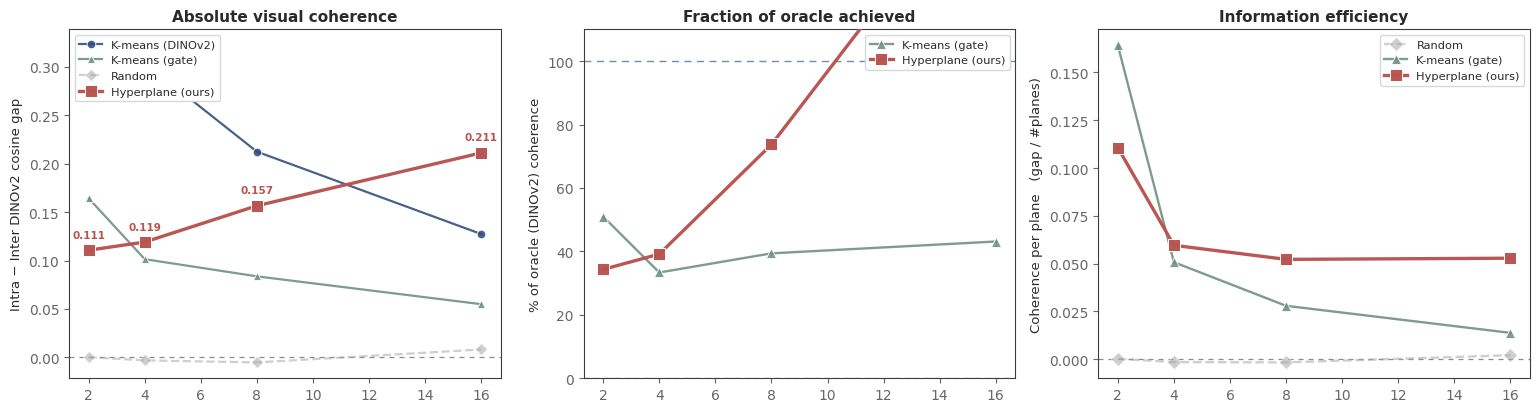

saved: results/apple/results_multiplane_final.png


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# 논문용 정리 그림 (위 셀의 `records` 재사용)
#   강조: Hyperplane(ours) ≥ K-means(gate) @ 동일 P-뉴런 예산
#   oracle = 상한선, K=16 = 저신뢰(≤5 filtered) 음영
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

assert 'records' in globals(), "먼저 위 multi-resolution 비교 셀을 실행하세요."

# ── Publication palette (muted, colorblind-friendly) ─────────────────────────
C = {
    'K-means (DINOv2)': '#2F4B7C',   # deep slate blue — oracle
    'Hyperplane (ours)':  '#B85450',   # muted brick — primary (ours)
    'K-means (gate)':     '#6B8E7E',   # sage green — matched baseline
    'Random':             '#A8A8A8',   # neutral gray
}
MK = {'K-means (DINOv2)': 'o', 'Hyperplane (ours)': 's', 'K-means (gate)': '^', 'Random': 'D'}

FIG_BG  = '#FFFFFF'
SHADE   = '#ECEFF3'   # cool gray band (low-confidence K)
GRID    = '#D5D9DE'
SPINE   = '#3D3D3D'
TEXT    = '#2A2A2A'
MUTED   = '#666666'
REFLINE = '#8A8A8A'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'axes.labelcolor': TEXT,
    'axes.edgecolor': SPINE,
    'axes.linewidth': 0.8,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'text.color': TEXT,
    'axes.titleweight': 'bold',
    'axes.titlesize': 11,
    'figure.facecolor': FIG_BG,
    'axes.facecolor': FIG_BG,
})

Ks = sorted({r['K'] for r in records})
LOWN_K = max(Ks)  # 가장 큰 region 수 = 저신뢰 구간

def S(metric, m):
    return [next((r[metric] for r in records if r['method']==m and r['K']==k), np.nan) for k in Ks]

def style(ax):
    ax.axvspan(LOWN_K/1.30, LOWN_K*1.18, color=SHADE, zorder=0, lw=0)
    ax.set_xscale('log', base=2); ax.set_xticks(Ks); ax.set_xticklabels(Ks)
    ax.set_xlabel('# regions   (planes:  1→2,  2→4,  3→8,  4→16)', fontsize=9.5, color=TEXT)
    ax.grid(color=GRID, alpha=0.85, lw=0.6, zorder=1)
    ax.tick_params(axis='both', labelsize=9)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    ax.spines['left'].set_color(SPINE)
    ax.spines['bottom'].set_color(SPINE)

fig, axs = plt.subplots(1, 3, figsize=(15.5, 4.7))

# ── Panel A: 절대 coherence (4 methods) ──────────────────────────────────────
axA = axs[0]
for m in ['K-means (DINOv2)', 'K-means (gate)', 'Random', 'Hyperplane (ours)']:
    emph = (m == 'Hyperplane (ours)')
    axA.plot(Ks, S('gap', m), marker=MK[m], color=C[m],
             lw=2.4 if emph else 1.6, ms=8.5 if emph else 6.2,
             ls='--' if m=='Random' else '-',
             alpha=0.98 if emph else (0.55 if m=='Random' else 0.88),
             zorder=6 if emph else 4, label=m,
             markeredgecolor='white', markeredgewidth=0.7)
for k, y in zip(Ks, S('gap', 'Hyperplane (ours)')):
    axA.annotate(f'{y:.3f}', (k, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=7.5, color=C['Hyperplane (ours)'], fontweight='600')
axA.axhline(0, color=REFLINE, lw=0.9, ls=(0, (4, 4)), zorder=2)
axA.set_ylabel('Intra − Inter DINOv2 cosine gap', fontsize=9.5)
axA.set_title('Absolute visual coherence', fontsize=11, fontweight='bold', color=TEXT)
axA.legend(fontsize=8.2, framealpha=1.0, edgecolor=GRID, facecolor=FIG_BG, loc='upper left')
# style(axA)

# ── Panel B: oracle 대비 달성률 (ours vs gate) ───────────────────────────────
axB = axs[1]
for m in ['K-means (gate)', 'Hyperplane (ours)']:
    emph = (m == 'Hyperplane (ours)')
    axB.plot(Ks, S('oracle_frac', m), marker=MK[m], color=C[m],
             lw=2.4 if emph else 1.7, ms=8.5 if emph else 6.8,
             alpha=0.98 if emph else 0.88, zorder=6 if emph else 4, label=m,
             markeredgecolor='white', markeredgewidth=0.7)
axB.axhline(100, color=C['K-means (DINOv2)'], lw=1.0, ls=(0, (5, 4)), alpha=0.65)
axB.axhline(0, color=REFLINE, lw=0.9, ls=(0, (4, 4)), zorder=2)
axB.set_ylabel('% of oracle (DINOv2) coherence', fontsize=9.5)
axB.set_title('Fraction of oracle achieved', fontsize=11, fontweight='bold', color=TEXT)
axB.set_ylim(0, 110)
axB.legend(fontsize=8.2, framealpha=1.0, edgecolor=GRID, facecolor=FIG_BG, loc='upper right')
# style(axB)

# ── Panel C: plane당 효율 (ours vs gate vs random) ───────────────────────────
axC = axs[2]
for m in ['Random', 'K-means (gate)', 'Hyperplane (ours)']:
    emph = (m == 'Hyperplane (ours)')
    axC.plot(Ks, S('gap_per_bit', m), marker=MK[m], color=C[m],
             lw=2.4 if emph else 1.7, ms=8.5 if emph else 6.8,
             ls='--' if m=='Random' else '-',
             alpha=0.98 if emph else (0.55 if m=='Random' else 0.88),
             zorder=6 if emph else 4, label=m,
             markeredgecolor='white', markeredgewidth=0.7)
axC.axhline(0, color=REFLINE, lw=0.9, ls=(0, (4, 4)), zorder=2)
axC.set_ylabel('Coherence per plane   (gap / #planes)', fontsize=9.5)
axC.set_title('Information efficiency', fontsize=11, fontweight='bold', color=TEXT)
axC.legend(fontsize=8.2, framealpha=1.0, edgecolor=GRID, facecolor=FIG_BG, loc='upper right')
# style(axC)

from pathlib import Path
RESULTS_DIR = Path(f'./results/{concept_tag}')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
save_path = RESULTS_DIR / 'results_multiplane_final.png'
fig.tight_layout(rect=[0, 0.02, 1, 0.92])
fig.savefig(save_path, dpi=160, bbox_inches='tight', facecolor=FIG_BG)
plt.show()
print(f'saved: {save_path}')


2 valid group(s)  (n≥10):
  000  n=51  intra=0.7449
  111  n=32  intra=0.5599
saved: results/apple/region_P3_up_blocks_1.png


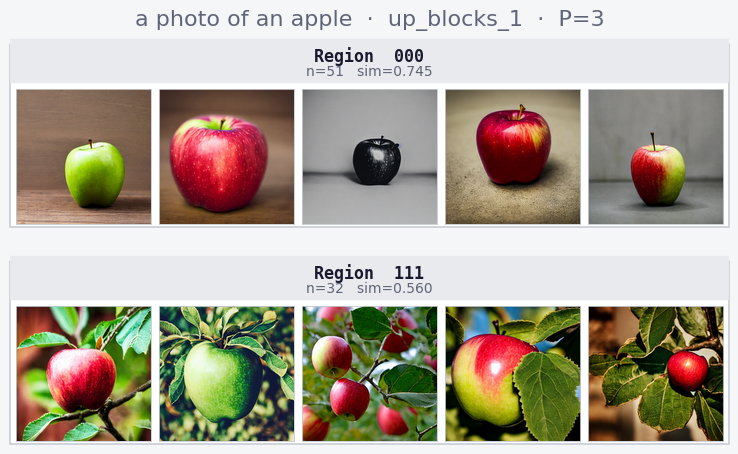

In [20]:
# ════════════════════════════════════════════════════════════════════════════
# Region 정성 시각화 — appendix  (n ≥ 5 group · 10 images · gray grid)
#   ※ 위 multi-resolution 셀(sel, hyperplane_code)을 먼저 실행
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.patches import FancyBboxPatch

INSPECT_P   = 3
N_SHOW      = 5      # 그룹당 이미지 수
IMG_COLS    = 5       # 5 × 2 grid per group
MIN_REGION_VIZ = 10   # 이 이상인 그룹만 표시
SAVE_FIG    = True
FIG_DPI     = 200

assert 'sel' in globals() and 'hyperplane_code' in globals(), \
    "먼저 multi-resolution 비교 셀을 실행하세요."

# ── 색상 ──────────────────────────────────────────────────────────────────
FIG_BG    = '#F5F6F8'   # 전체 배경 (밝은 회색)
PANEL_BG  = '#FFFFFF'   # 각 그룹 패널 배경
BORDER    = '#C4C9D1'   # 패널 테두리 / 이미지 구분선
TITLE_BG  = '#E8EAED'   # 레이블 배경
TEXT      = '#1A1A2E'
MUTED     = '#5F6478'

plt.rcParams.update({
    'font.family'     : 'sans-serif',
    'font.sans-serif' : ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'text.color'      : TEXT,
})

planes_ins = sel[:INSPECT_P]
code_ins   = hyperplane_code(planes_ins)
Kreg       = 2 ** INSPECT_P
bin_fmt    = f"0{INSPECT_P}b"
IMG_ROWS   = int(np.ceil(N_SHOW / IMG_COLS))

def region_intra(idxs):
    if len(idxs) < 2:
        return np.nan
    e   = dino_embeds[idxs]
    sim = e @ e.T
    iu  = np.triu_indices(len(idxs), k=1)
    return float(sim[iu].mean())

summary = [(r, np.where(code_ins == r)[0]) for r in range(Kreg)]
summary = [(r, idxs, region_intra(idxs)) for r, idxs in summary]
groups  = [(r, idxs, intra) for r, idxs, intra in summary if len(idxs) >= MIN_REGION_VIZ]
groups.sort(key=lambda t: t[0])

concept_tag = globals().get('CONCEPT', 'concept')
block_tag   = globals().get('INJECT_BLOCK', 'block').replace('.', '_')

print(f"{len(groups)} valid group(s)  (n≥{MIN_REGION_VIZ}):")
for r, idxs, intra in groups:
    print(f"  {format(r, bin_fmt)}  n={len(idxs)}  intra={intra:.4f}")

if not groups:
    print(f"No valid groups (all n < {MIN_REGION_VIZ}).")
else:
    n_grp = len(groups)

    # ── 레이아웃 상수 (세로 스택) ─────────────────────────────────────────
    CELL_W     = 1.35
    CELL_H     = 1.35
    GAP        = 0.08
    GROUP_PAD  = 0.40   # 그룹 간 세로 여백
    LABEL_H    = 0.42
    MARGIN_T   = 0.50
    MARGIN_B   = 0.18
    MARGIN_LR  = 0.20

    panel_w = IMG_COLS * CELL_W + (IMG_COLS - 1) * GAP
    panel_h = IMG_ROWS * CELL_H + (IMG_ROWS - 1) * GAP + LABEL_H

    fig_w = panel_w + 2 * MARGIN_LR
    fig_h = n_grp * panel_h + (n_grp - 1) * GROUP_PAD + MARGIN_T + MARGIN_B

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=FIG_BG)

    # 그룹별 패널 y 시작 (inch, 아래→위; gi=0 이 위쪽)
    y_starts = [
        MARGIN_B + (n_grp - 1 - gi) * (panel_h + GROUP_PAD)
        for gi in range(n_grp)
    ]
    x_start = MARGIN_LR

    for gi, (r, idxs, intra) in enumerate(groups):
        x0  = x_start / fig_w
        y0  = y_starts[gi] / fig_h
        pw  = panel_w / fig_w
        ph  = panel_h / fig_h

        bg = FancyBboxPatch(
            (x0 - 0.008, y0 - 0.006),
            pw + 0.016, ph + 0.012,
            boxstyle='round,pad=0',
            linewidth=1.1,
            edgecolor=BORDER, facecolor=PANEL_BG,
            transform=fig.transFigure, clip_on=False, zorder=0)
        fig.add_artist(bg)

        lbl_h_frac = (LABEL_H - 0.06) / fig_h
        lbl_bg = FancyBboxPatch(
            (x0 - 0.008, y0 + ph - lbl_h_frac),
            pw + 0.016, lbl_h_frac + 0.018,
            boxstyle='round,pad=0',
            linewidth=0, facecolor=TITLE_BG,
            transform=fig.transFigure, clip_on=False, zorder=1)
        fig.add_artist(lbl_bg)

        fig.text(
            x0 + pw / 2,
            y0 + ph - lbl_h_frac / 2 + 0.02,
            f"Region  {format(r, bin_fmt)}",
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            fontfamily='monospace', color=TEXT,
            transform=fig.transFigure, zorder=2)

        intra_str = f"n={len(idxs)}   sim={intra:.3f}" if not np.isnan(intra) else f"n={len(idxs)}"
        fig.text(
            x0 + pw / 2,
            y0 + ph - lbl_h_frac / 2 - 0.0,
            intra_str,
            ha='center', va='top',
            fontsize=10, color=MUTED,
            transform=fig.transFigure, zorder=2)

        show = idxs[:N_SHOW]
        img_y_base = y_starts[gi]

        for k in range(IMG_ROWS * IMG_COLS):
            row = k // IMG_COLS
            col = k % IMG_COLS

            ax_x = (x_start + col * (CELL_W + GAP)) / fig_w
            ax_y = (img_y_base + (IMG_ROWS - 1 - row) * (CELL_H + GAP)) / fig_h
            ax_w = CELL_W / fig_w
            ax_h = CELL_H / fig_h

            ax = fig.add_axes([ax_x, ax_y, ax_w, ax_h])

            if k < len(show):
                ax.imshow(np.array(images[show[k]]), interpolation='lanczos')
            else:
                ax.set_facecolor('#E0E0E0')

            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(BORDER)
                sp.set_linewidth(0.6)

    # 전체 제목
    fig.text(
        0.5, 1.0 - (MARGIN_T * 0.25) / fig_h,
        f"{PROMPT}  ·  {block_tag}  ·  P={INSPECT_P}",
        ha='center', va='top',
        fontsize=16, color=MUTED,
        transform=fig.transFigure)

    out_name = f'region_P{INSPECT_P}_{block_tag}.png'
    if SAVE_FIG:
        from pathlib import Path
        RESULTS_DIR = Path(f'./results/{concept_tag}')
        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        save_path = RESULTS_DIR / out_name
        fig.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight',
                    facecolor=FIG_BG, pad_inches=0.12)
        print(f'saved: {save_path}')
    plt.show()


In [21]:
# ════════════════════════════════════════════════════════════════════════════
# [추가] 군집 알고리즘 비교: K-means / GMM / Agglomerative (모두 gate 입력 동일)
#   · 입력은 ours·K-means(gate)와 동일: 선택된 P개 뉴런의 연속 gate 값
#   · "부호(ours)를 못 이기는 게 K-means 특정 아티팩트인지" 확인용
#   · BLOCK 20을 먼저 실행해야 함 (gate_img, sel, dino_embeds, hyperplane_code,
#     gap_filtered, N_img, MAX_PLANES 재사용)
# ════════════════════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

print(f"{'P':>2} {'K':>3}  {'method':22s}  {'gap':>8}  {'sil':>7}  groups   imgs")
algo_records = []
for P in range(1, MAX_COMPARE_PLANES + 1):
    K = 2 ** P
    feat_P = StandardScaler().fit_transform(gate_img[:, sel[:P]])   # (N, P) — 동일 입력

    labelings = {
        'Hyperplane (ours)':   hyperplane_code(sel[:P]),
        'K-means (gate)':      KMeans(K, random_state=42, n_init=10).fit_predict(feat_P),
        'GMM (gate)':          GaussianMixture(K, random_state=42, n_init=5).fit_predict(feat_P),
        'Agglomerative (gate)':AgglomerativeClustering(K, linkage='ward').fit_predict(feat_P),
    }
    for name, lab in labelings.items():
        r = gap_filtered(dino_embeds, lab)
        r.update(P=P, K=K, method=name)
        algo_records.append(r)
        print(f"{P:>2} {K:>3}  {name:22s}  {r['gap']:+.4f}  {r['sil']:+.4f}  "
              f"{r['n_groups']:>2}/{K:<2}   {r['n_used']:>3}/{N_img}")
    print()

# ── 요약: 각 K에서 ours가 모든 gate-군집을 이겼는지 체크 ──────────────────────
print("="*60)
for P in range(1, MAX_COMPARE_PLANES + 1):
    K = 2 ** P
    rows = {r['method']: r['gap'] for r in algo_records if r['K'] == K}
    ours = rows['Hyperplane (ours)']
    others = {m: g for m, g in rows.items() if m != 'Hyperplane (ours)'}
    win = all(ours >= g for g in others.values())
    best_other = max(others, key=others.get)
    print(f"K={K}: ours={ours:+.4f} | best baseline={best_other} ({others[best_other]:+.4f}) "
          f"| ours wins: {win}")


 P   K  method                       gap      sil  groups   imgs
 1   2  Hyperplane (ours)       +0.1107  +0.1306   2/2    100/100
 1   2  K-means (gate)          +0.1643  +0.1876   2/2    100/100
 1   2  GMM (gate)              +0.1134  +0.1297   2/2    100/100
 1   2  Agglomerative (gate)    +0.1650  +0.1974   2/2    100/100

 2   4  Hyperplane (ours)       +0.1191  +0.1438   2/4     93/100
 2   4  K-means (gate)          +0.1014  +0.0034   4/4    100/100
 2   4  GMM (gate)              +0.0995  +0.0094   4/4    100/100
 2   4  Agglomerative (gate)    +0.0884  -0.0168   4/4    100/100

 3   8  Hyperplane (ours)       +0.1566  +0.1840   2/8     83/100
 3   8  K-means (gate)          +0.0837  -0.0482   7/8     98/100
 3   8  GMM (gate)              +0.0895  -0.0552   6/8     96/100
 3   8  Agglomerative (gate)    +0.0596  -0.0775   6/8     95/100

 4  16  Hyperplane (ours)       +0.2112  +0.2431   2/16    74/100
 4  16  K-means (gate)          +0.0549  -0.0340   7/16    77/100
 4  16  

1 valid group(s)  (n≥5):
  0  n=100  intra=0.6198
saved: results/apple/results_region_P0_up_blocks_1.png


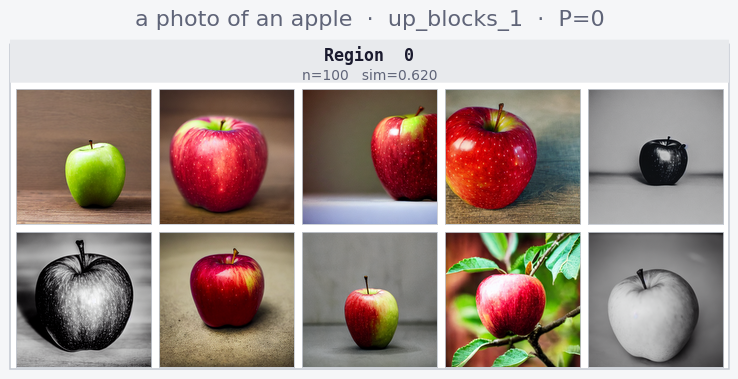

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# Region 정성 시각화 — appendix  (n ≥ 5 group · 10 images · gray grid)
#   ※ 위 multi-resolution 셀(sel, hyperplane_code)을 먼저 실행
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.patches import FancyBboxPatch

INSPECT_P   = 0
N_SHOW      = 10      # 그룹당 이미지 수
IMG_COLS    = 5       # 5 × 2 grid per group
MIN_REGION_VIZ = 5   # 이 이상인 그룹만 표시
SAVE_FIG    = True
FIG_DPI     = 200

assert 'sel' in globals() and 'hyperplane_code' in globals(), \
    "먼저 multi-resolution 비교 셀을 실행하세요."

# ── 색상 ──────────────────────────────────────────────────────────────────
FIG_BG    = '#F5F6F8'   # 전체 배경 (밝은 회색)
PANEL_BG  = '#FFFFFF'   # 각 그룹 패널 배경
BORDER    = '#C4C9D1'   # 패널 테두리 / 이미지 구분선
TITLE_BG  = '#E8EAED'   # 레이블 배경
TEXT      = '#1A1A2E'
MUTED     = '#5F6478'

plt.rcParams.update({
    'font.family'     : 'sans-serif',
    'font.sans-serif' : ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'text.color'      : TEXT,
})

planes_ins = sel[:INSPECT_P]
code_ins   = hyperplane_code(planes_ins)
Kreg       = 2 ** INSPECT_P
bin_fmt    = f"0{INSPECT_P}b"
IMG_ROWS   = int(np.ceil(N_SHOW / IMG_COLS))

def region_intra(idxs):
    if len(idxs) < 2:
        return np.nan
    e   = dino_embeds[idxs]
    sim = e @ e.T
    iu  = np.triu_indices(len(idxs), k=1)
    return float(sim[iu].mean())

summary = [(r, np.where(code_ins == r)[0]) for r in range(Kreg)]
summary = [(r, idxs, region_intra(idxs)) for r, idxs in summary]
groups  = [(r, idxs, intra) for r, idxs, intra in summary if len(idxs) >= MIN_REGION_VIZ]
groups.sort(key=lambda t: t[0])

concept_tag = globals().get('CONCEPT', 'concept')
block_tag   = globals().get('INJECT_BLOCK', 'block').replace('.', '_')

print(f"{len(groups)} valid group(s)  (n≥{MIN_REGION_VIZ}):")
for r, idxs, intra in groups:
    print(f"  {format(r, bin_fmt)}  n={len(idxs)}  intra={intra:.4f}")

if not groups:
    print(f"No valid groups (all n < {MIN_REGION_VIZ}).")
else:
    n_grp = len(groups)

    # ── 레이아웃 상수 ─────────────────────────────────────────────────────
    CELL_W     = 1.35   # 이미지 셀 폭  (inch)
    CELL_H     = 1.35   # 이미지 셀 높이
    GAP        = 0.08   # 이미지 간격  (inch)
    GROUP_PAD  = 0.55   # 그룹 간 여백 (inch)
    LABEL_H    = 0.42   # 레이블 행 높이 (inch)
    MARGIN_T   = 0.50   # 전체 상단 여백
    MARGIN_B   = 0.18   # 전체 하단 여백
    MARGIN_LR  = 0.20   # 좌우 여백

    panel_w = IMG_COLS * CELL_W + (IMG_COLS - 1) * GAP
    panel_h = IMG_ROWS * CELL_H + (IMG_ROWS - 1) * GAP + LABEL_H

    fig_w = n_grp * panel_w + (n_grp - 1) * GROUP_PAD + 2 * MARGIN_LR
    fig_h = panel_h + MARGIN_T + MARGIN_B

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=FIG_BG)

    # 그룹별 패널 x 시작 위치 계산
    x_starts = [MARGIN_LR + gi * (panel_w + GROUP_PAD) for gi in range(n_grp)]

    for gi, (r, idxs, intra) in enumerate(groups):
        x0  = x_starts[gi] / fig_w
        y0  = MARGIN_B     / fig_h
        pw  = panel_w      / fig_w
        ph  = panel_h      / fig_h

        # 패널 배경 + 테두리
        bg = FancyBboxPatch(
            (x0 - 0.008, y0 - 0.006),
            pw + 0.016, ph + 0.012,
            boxstyle='round,pad=0',
            linewidth=1.1,
            edgecolor=BORDER, facecolor=PANEL_BG,
            transform=fig.transFigure, clip_on=False, zorder=0)
        fig.add_artist(bg)

        # 레이블 배경 띠
        lbl_h_frac = (LABEL_H - 0.06) / fig_h
        lbl_bg = FancyBboxPatch(
            (x0 - 0.008, y0 + ph - lbl_h_frac),
            pw + 0.016, lbl_h_frac + 0.018,
            boxstyle='round,pad=0',
            linewidth=0, facecolor=TITLE_BG,
            transform=fig.transFigure, clip_on=False, zorder=1)
        fig.add_artist(lbl_bg)

        # 레이블 텍스트 (region code + n + intra)
        fig.text(
            x0 + pw / 2,
            y0 + ph - lbl_h_frac / 2 + 0.025,
            f"Region  {format(r, bin_fmt)}",
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            fontfamily='monospace', color=TEXT,
            transform=fig.transFigure, zorder=2)

        intra_str = f"n={len(idxs)}   sim={intra:.3f}" if not np.isnan(intra) else f"n={len(idxs)}"
        fig.text(
            x0 + pw / 2,
            y0 + ph - lbl_h_frac / 2 - 0.01,
            intra_str,
            ha='center', va='top',
            fontsize=10, color=MUTED,
            transform=fig.transFigure, zorder=2)

        # 이미지 그리드
        image_area_h = panel_h - LABEL_H
        show = idxs[:N_SHOW]

        for k in range(IMG_ROWS * IMG_COLS):
            row = k // IMG_COLS
            col = k  % IMG_COLS

            ax_x = (x_starts[gi] + col * (CELL_W + GAP)) / fig_w
            ax_y = (MARGIN_B + (IMG_ROWS - 1 - row) * (CELL_H + GAP)) / fig_h
            ax_w = CELL_W / fig_w
            ax_h = CELL_H / fig_h

            ax = fig.add_axes([ax_x, ax_y, ax_w, ax_h])

            if k < len(show):
                img = np.array(images[show[k]])
                ax.imshow(img, interpolation='lanczos')
            else:
                ax.set_facecolor('#E0E0E0')

            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(BORDER)
                sp.set_linewidth(0.6)

    # 전체 제목
    fig.text(
        0.5, 1.0 - (MARGIN_T * 0.25) / fig_h,
        f"{PROMPT}  ·  {block_tag}  ·  P={INSPECT_P}",
        ha='center', va='top',
        fontsize=16, color=MUTED,
        transform=fig.transFigure)

    out_name = f'results_region_P{INSPECT_P}_{block_tag}.png'
    if SAVE_FIG:
        from pathlib import Path
        RESULTS_DIR = Path(f'./results/{concept_tag}')
        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        save_path = RESULTS_DIR / out_name
        fig.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight',
                    facecolor=FIG_BG, pad_inches=0.12)
        print(f'saved: {save_path}')
    plt.show()


In [ ]:
from load import save_cache
save_cache(
    cfg, "neuron_selection",
    ff_in=ff_in, W2=W2, b2=b2, binary=binary, pre_acts=pre_acts,
    sel=sel, dino_embeds=dino_embeds, gate_img=gate_img,
    records=records, cand_idx=cand_idx,
    N_SELECT_PLANES=N_SELECT_PLANES, MAX_COMPARE_PLANES=MAX_COMPARE_PLANES, MIN_REGION=MIN_REGION,
)

cache saved → /project/dam/data/apple/up_blocks_1/_cache/neuron_selection.pt


PosixPath('/project/dam/data/apple/up_blocks_1/_cache/neuron_selection.pt')